# 7-A1 作業：建立自己的投資系統

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/7-A1_own_portfolio.ipynb)

**對應影片**：第 7 章 作業 7-A1【投資組合】建立自己的投資系統

**和影片的差異**

- 新增的起始筆記本：7-4 的合成 K 線與等權重組合函式已放好，改幣種清單與策略即可。

上個單元用很簡單的策略建構了 altcoin 交易系統。請嘗試建構自己的「單一策略、多商品」系統，並分享給大家！

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

In [3]:
import finlab_crypto

finlab_crypto.setup()

# TODO: 換成你想交易的幣種
symbols = ['ETHBTC', 'BNBBTC', 'SOLBTC', 'XRPBTC', 'ADABTC']
START = '2022-01-01'
ohlcvs = {s: finlab_crypto.crawler.get_all_binance(s, '4h') for s in symbols}

ETHBTC 4h: 20140 candles (2017-07-14 ~ 2026-09-24 08:00 UTC)


BNBBTC 4h: 20140 candles (2017-07-14 ~ 2026-09-24 08:00 UTC)


SOLBTC 4h: 14150 candles (2020-04-10 ~ 2026-09-24 08:00 UTC)


XRPBTC 4h: 19474 candles (2017-11-02 ~ 2026-09-24 08:00 UTC)


ADABTC 4h: 19304 candles (2017-11-30 ~ 2026-09-24 08:00 UTC)


In [4]:
import numpy as np
import pandas as pd


def concat_assets(ohlcvs, symbols, freq='4h'):
    """把多個幣種的 K 線首尾相接成一條「合成」K 線，讓一組參數同時在所有幣種上回測。"""
    returns = pd.Series(np.concatenate([ohlcvs[s].close.pct_change().values for s in symbols]))
    close = (returns.fillna(0) + 1).cumprod()

    def scaled(column):
        # 開高低相對於收盤價的比例不變，換算到合成的收盤價上
        return np.concatenate([(ohlcvs[s][column] / ohlcvs[s].close).values for s in symbols]) * close.values

    return pd.DataFrame({
        'open': scaled('open'),
        'high': scaled('high'),
        'low': scaled('low'),
        'close': close.values,
        'volume': np.concatenate([ohlcvs[s].volume.values for s in symbols]),
    }, index=pd.date_range('2000-01-01', periods=len(close), freq=freq)).dropna()


ohlcv_comb = concat_assets({s: ohlcv.loc[START:] for s, ohlcv in ohlcvs.items()}, symbols)

In [5]:
from finlab_crypto import Strategy
from finlab_crypto.indicators import trends


@Strategy(name='sma', n1=20, n2=40)
def trend_strategy(ohlcv):
    fast = trends[trend_strategy.name](ohlcv.close, trend_strategy.n1)
    slow = trends[trend_strategy.name](ohlcv.close, trend_strategy.n2)

    entries = (fast > slow) & (fast.shift() < slow.shift())
    exits = (fast < slow) & (fast.shift() > slow.shift())

    figures = {
        'overlaps': {
            'trend1': fast,
            'trend2': slow,
        }
    }
    return entries, exits, figures

## 在合成 K 線上最佳化

TODO：換成你的策略與參數範圍。

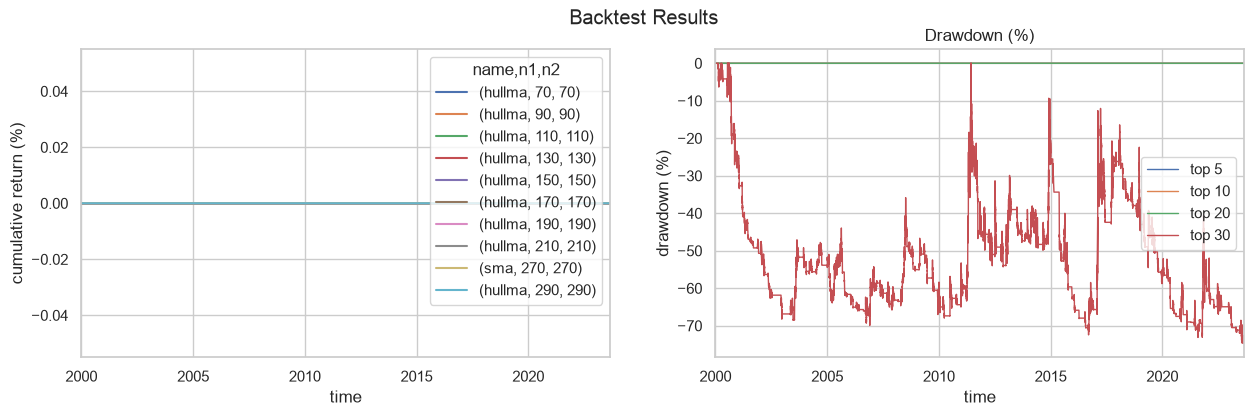

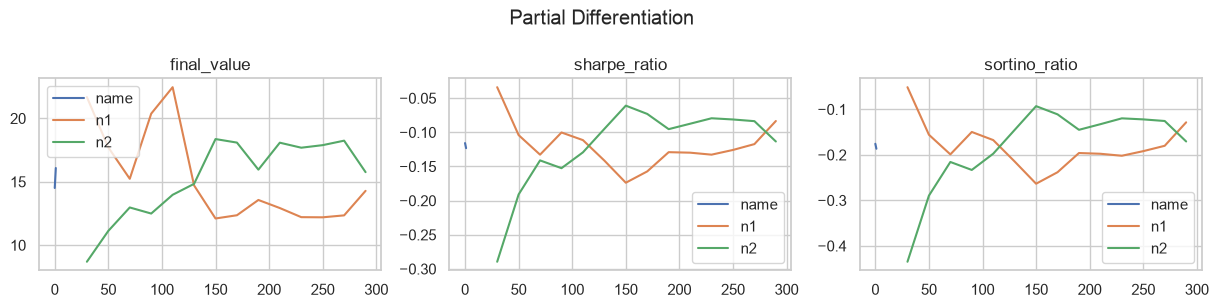

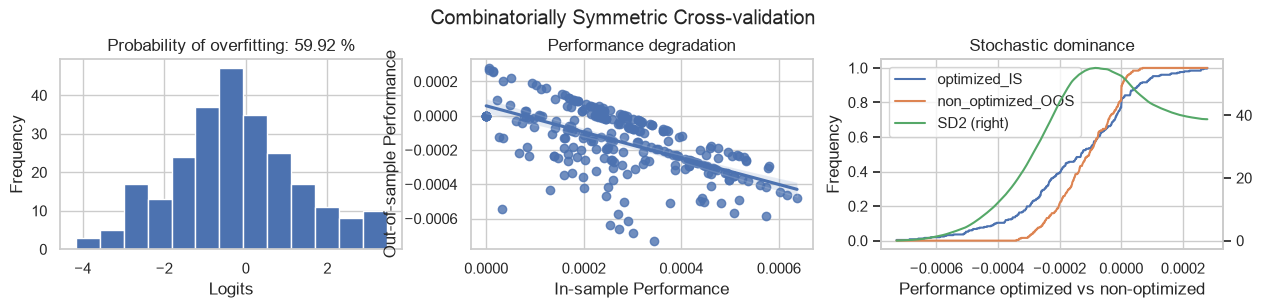

In [6]:
step = 90 if QUICK_RUN else 20
portfolio = trend_strategy.backtest(ohlcv_comb, variables={
    'name': ['sma', 'hullma'],
    'n1': np.arange(30, 300, step),
    'n2': np.arange(30, 300, step),
}, freq='4h', plot=True)

## 選定參數，每個幣種分別回測再等權重組合

In [7]:
import matplotlib.pyplot as plt


def plot_equal_weight(strategy, variables):
    """每個幣種分別回測，再等權重組合成一個投資組合。"""
    equity = pd.DataFrame({
        symbol: strategy.backtest(ohlcv, variables, freq='4h').cumulative_returns()
        for symbol, ohlcv in ohlcvs.items()
    })
    (equity + 1).plot(logy=True, title='Cumulative return by symbol')
    plt.show()

    daily = (equity + 1).pct_change().fillna(0)
    (daily.mean(axis=1) + 1).cumprod().plot(title='Equal-weight portfolio')
    plt.show()

name    n1   n2 
sma     110  170    0.145568
             150    0.137101
             210    0.133722
hullma  30   70     0.094439
sma     90   270    0.084504
Name: sharpe_ratio, dtype: float64

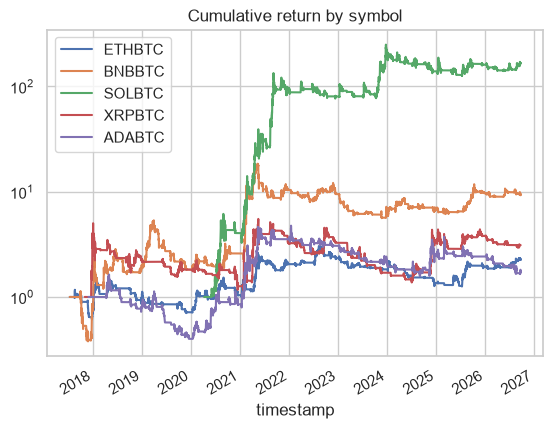

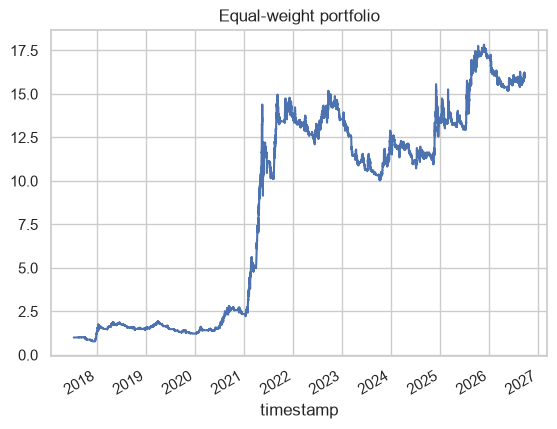

In [8]:
sharpe = portfolio.sharpe_ratio().replace([np.inf, -np.inf], np.nan)
display(sharpe.nlargest(5))

best_variables = dict(zip(portfolio.wrapper.columns.names, sharpe.idxmax()))
plot_equal_weight(trend_strategy, best_variables)